# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.


## 1. Problem Statement


Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.


## 2. Project Objectives


- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Examine seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based recommendations and conclusions.


## 3. Dataset


The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The dataset will be used to study seasonal agricultural performance and identify meaningful patterns and differences.


## 4. Initial Data Understanding


### Import Required Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


### Load Dataset


In [4]:
file_path = 'seasonal_agriculture_performance_dataset.csv'
df = pd.read_csv(file_path)

print('Dataset loaded successfully!')


Dataset loaded successfully!


### Display Top 5 Rows


In [5]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Display Dataset Shape


In [6]:
print('Number of Rows:', df.shape[0])
print('Number of Columns:', df.shape[1])


Number of Rows: 4000
Number of Columns: 28


### Examine Dataset Structure


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 5. Data Quality Analysis


### Check Missing Values


In [8]:
missing_values = df.isnull().sum()
missing_values


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


### Missing Value Percentage


In [9]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
missing_percentage[missing_percentage > 0]


,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8


### Handle Missing Values


In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

print('Missing values after treatment:')
df.isnull().sum()


Missing values after treatment:


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


### Check Duplicate Records


In [11]:
print('Duplicate records:', df.duplicated().sum())


Duplicate records: 0


### Handle Duplicate Records


In [12]:
df = df.drop_duplicates()
print('Duplicate records after treatment:', df.duplicated().sum())


Duplicate records after treatment: 0


### Check Duplicate Farm IDs


In [13]:
if 'Farm_ID' in df.columns:
    print('Duplicate Farm_ID values:', df['Farm_ID'].duplicated().sum())


Duplicate Farm_ID values: 0


## 6. Feature/Variable Review


### Review Data Types


In [14]:
df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### Review Column Names


In [15]:
df.columns.tolist()


['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

### Review Categorical Variables


In [16]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print(categorical_columns)

for col in categorical_columns:
    print(f'\n{col}')
    print(df[col].value_counts().head(10))


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
SF13976    1
SF13975    1
Name: count, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Dri

### Review Numerical Variables


In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numerical_columns)


['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


### Review Unique Values


In [18]:
for col in categorical_columns:
    print(f'{col}: {df[col].nunique()} unique values')


Farm_ID: 4000 unique values
State: 8 unique values
District: 10 unique values
Crop: 8 unique values
Season: 3 unique values
Irrigation_Method: 4 unique values


## 7. Statistical Analysis


### Numerical Statistical Summary


In [19]:
df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


### Categorical Statistical Summary


In [20]:
df.describe(include='object')


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


### Mean and Median Comparison


In [21]:
summary_stats = pd.DataFrame({
    'Mean': df.select_dtypes(include=np.number).mean(),
    'Median': df.select_dtypes(include=np.number).median(),
    'Standard Deviation': df.select_dtypes(include=np.number).std()
}).round(2)

summary_stats


,Mean,Median,Standard Deviation
Farm_Area_Hectares,7.89,7.90,4.22
Rainfall_mm,600.92,582.00,287.19
Avg_Temperature_C,26.82,26.90,3.82
Humidity_pct,63.21,63.00,11.96
Sunlight_Hours_Day,7.32,7.30,1.12
Soil_pH,6.70,6.69,0.64
Soil_Moisture_pct,26.51,26.40,6.68
Nitrogen_kg_ha,120.25,120.10,31.22
Phosphorus_kg_ha,57.78,57.50,17.02
Potassium_kg_ha,104.76,105.10,27.74


## 8. Univariate Analysis


### Season Distribution


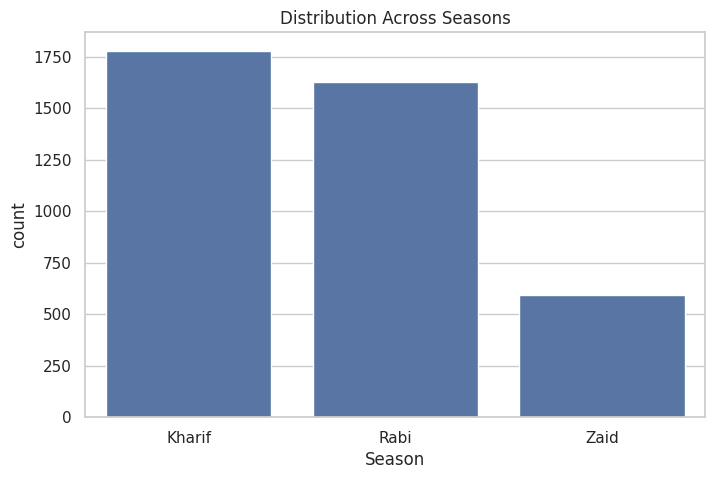

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Season')
plt.title('Distribution Across Seasons')
plt.show()


### Crop Distribution


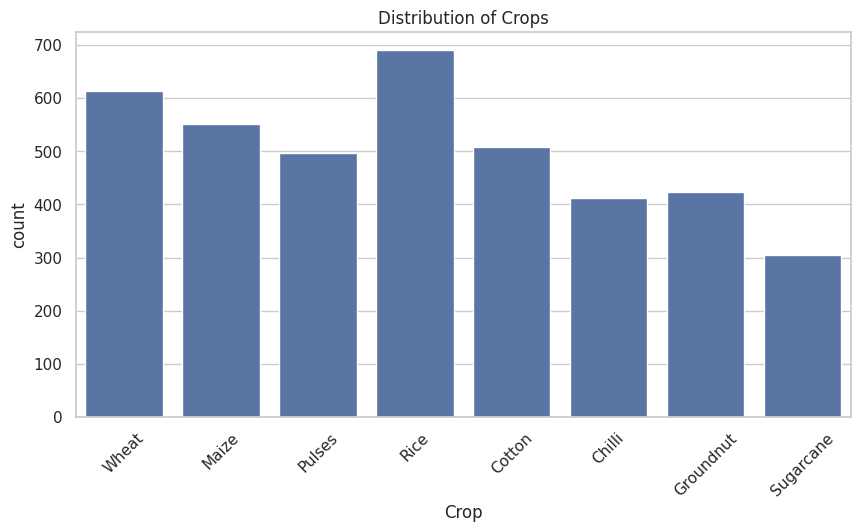

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Crop')
plt.title('Distribution of Crops')
plt.xticks(rotation=45)
plt.show()


### State Distribution


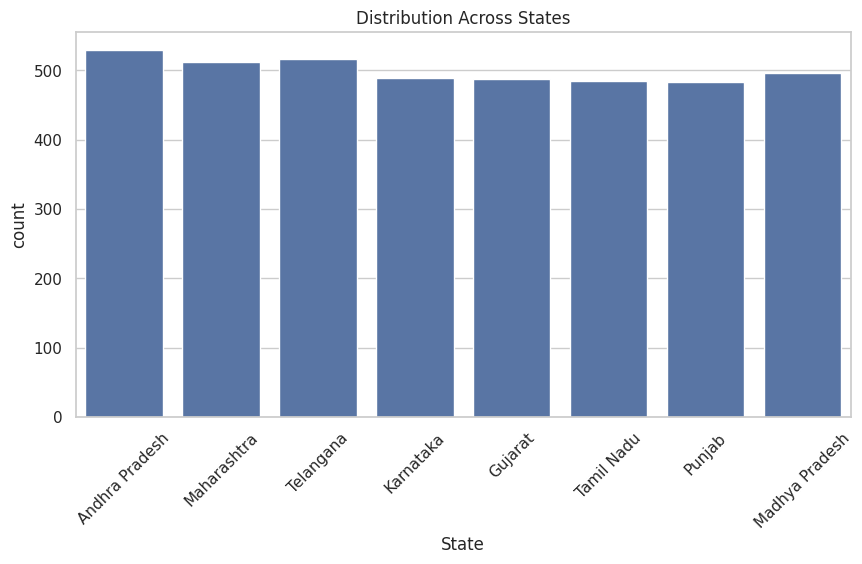

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='State')
plt.title('Distribution Across States')
plt.xticks(rotation=45)
plt.show()


### Irrigation Method Distribution


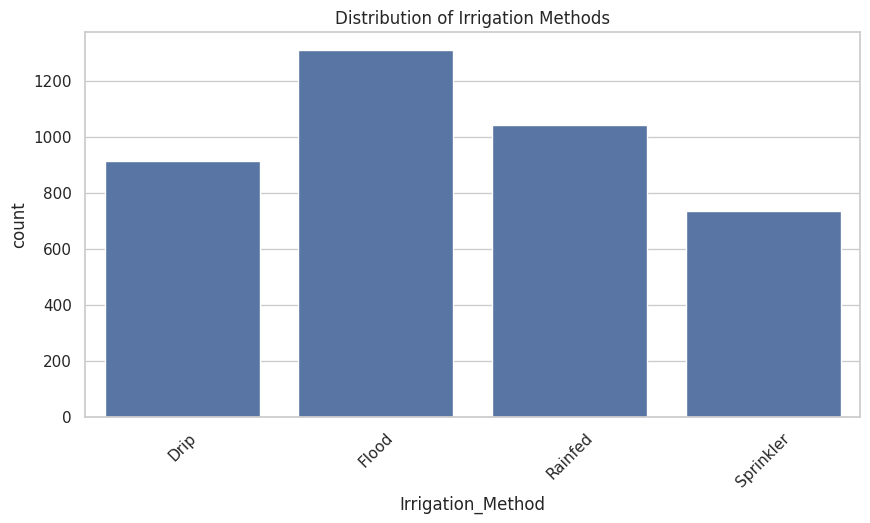

In [25]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Irrigation_Method')
plt.title('Distribution of Irrigation Methods')
plt.xticks(rotation=45)
plt.show()


### Yield Distribution


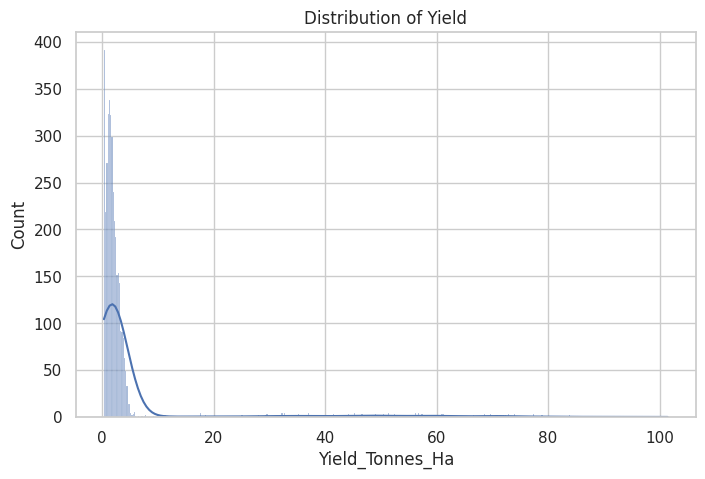

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Yield_Tonnes_Ha', kde=True)
plt.title('Distribution of Yield')
plt.show()


### Production Distribution


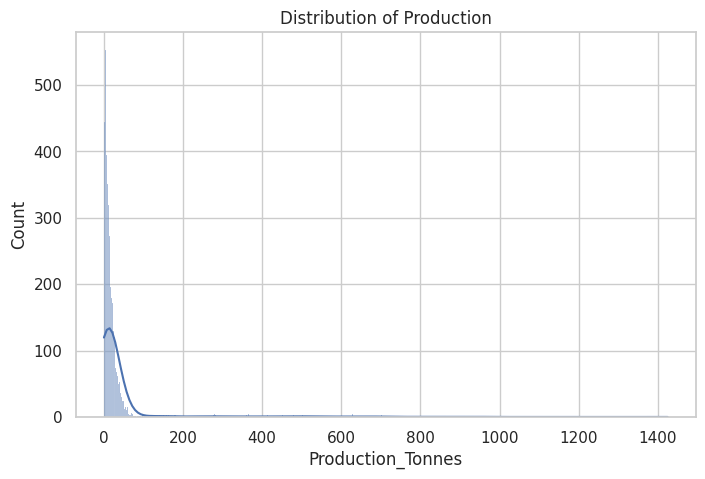

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Production_Tonnes', kde=True)
plt.title('Distribution of Production')
plt.show()


### Profit Distribution


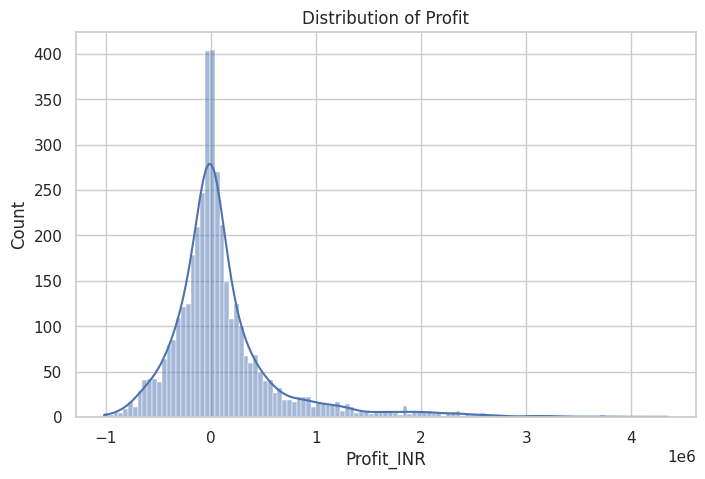

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Profit_INR', kde=True)
plt.title('Distribution of Profit')
plt.show()


## 9. Outlier Analysis


### Yield Outliers


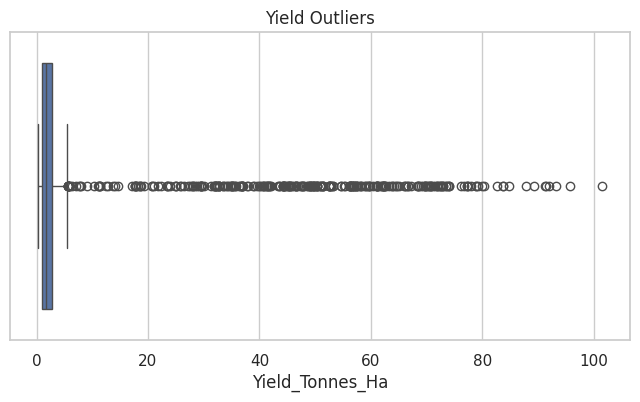

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Yield_Tonnes_Ha'])
plt.title('Yield Outliers')
plt.show()


### Production Outliers


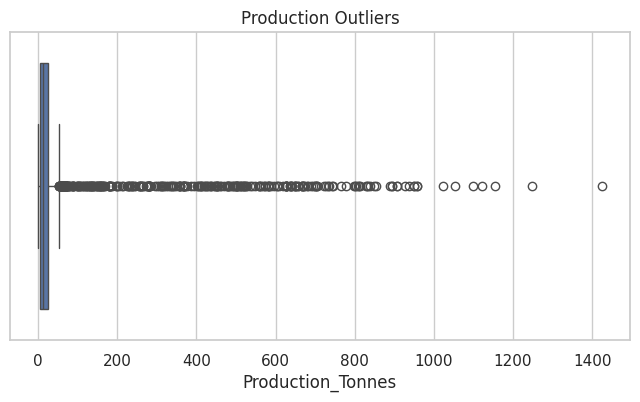

In [30]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Production_Tonnes'])
plt.title('Production Outliers')
plt.show()


### Profit Outliers


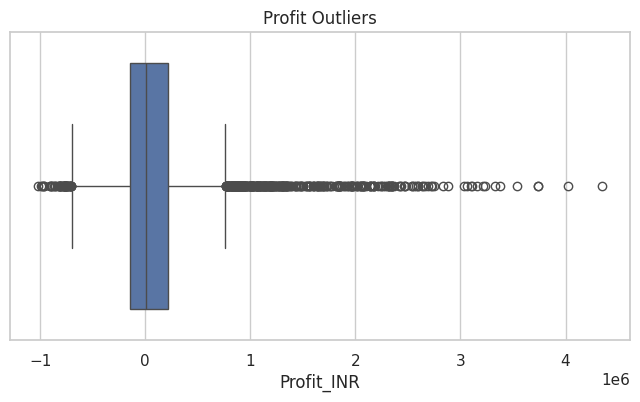

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Profit_INR'])
plt.title('Profit Outliers')
plt.show()


### Rainfall Outliers


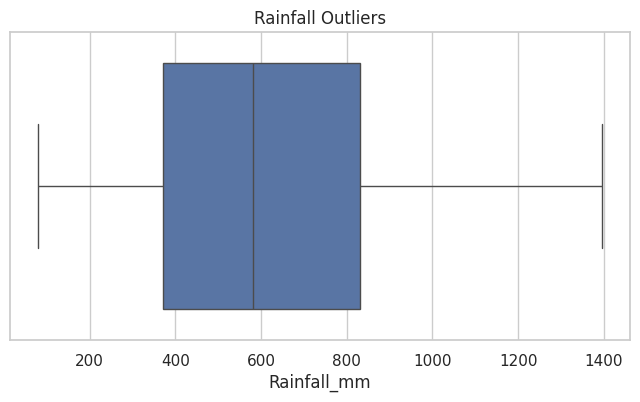

In [32]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Rainfall_mm'])
plt.title('Rainfall Outliers')
plt.show()


### Water Usage Outliers


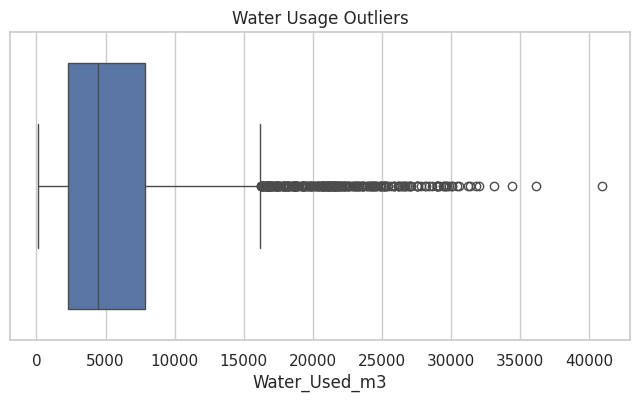

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Water_Used_m3'])
plt.title('Water Usage Outliers')
plt.show()


### Disease/Pest Risk Outliers


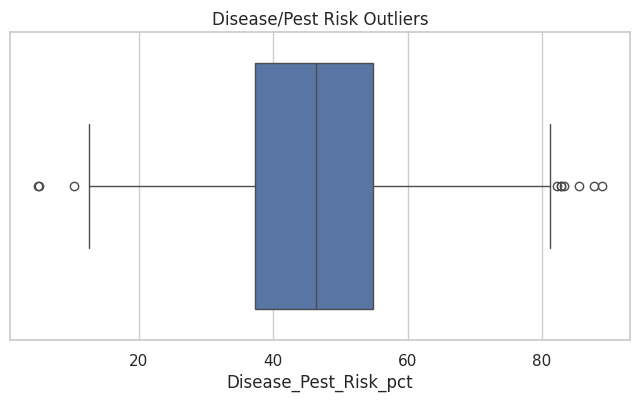

In [34]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Disease_Pest_Risk_pct'])
plt.title('Disease/Pest Risk Outliers')
plt.show()


## 10. Bivariate Analysis


### Season vs Yield


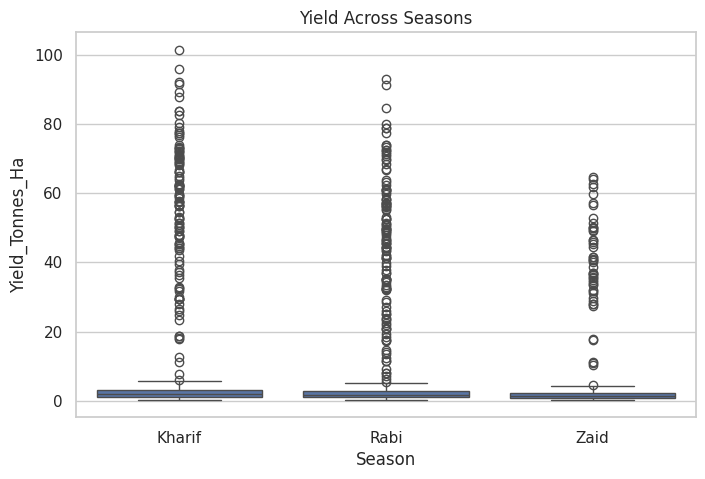

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title('Yield Across Seasons')
plt.show()


### Season vs Production


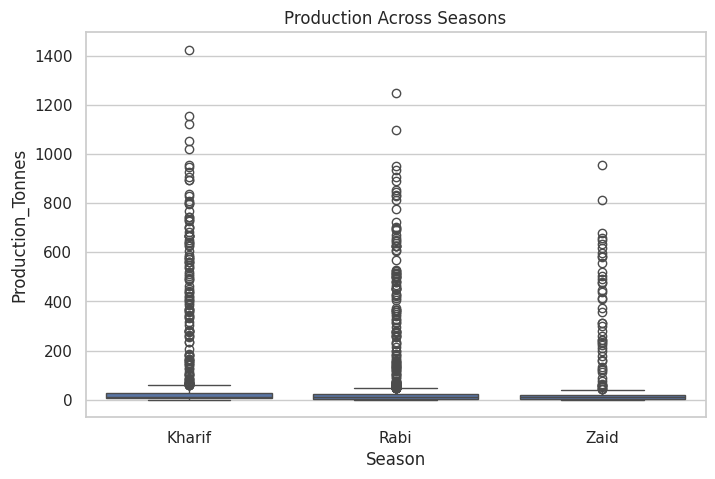

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Production_Tonnes')
plt.title('Production Across Seasons')
plt.show()


### Season vs Profit


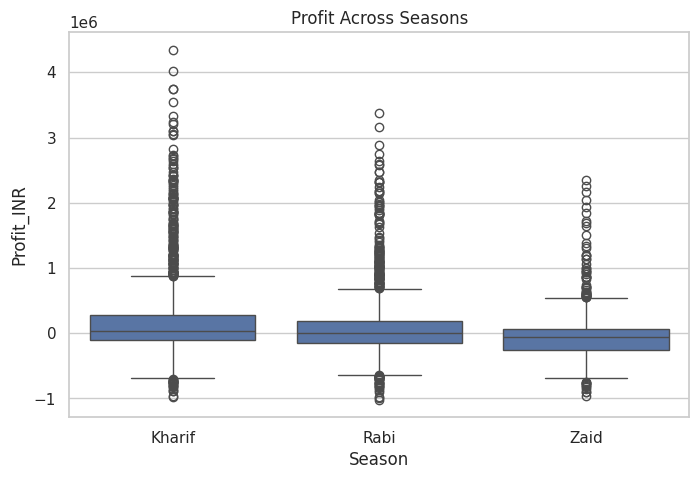

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Profit_INR')
plt.title('Profit Across Seasons')
plt.show()


### Season vs Rainfall


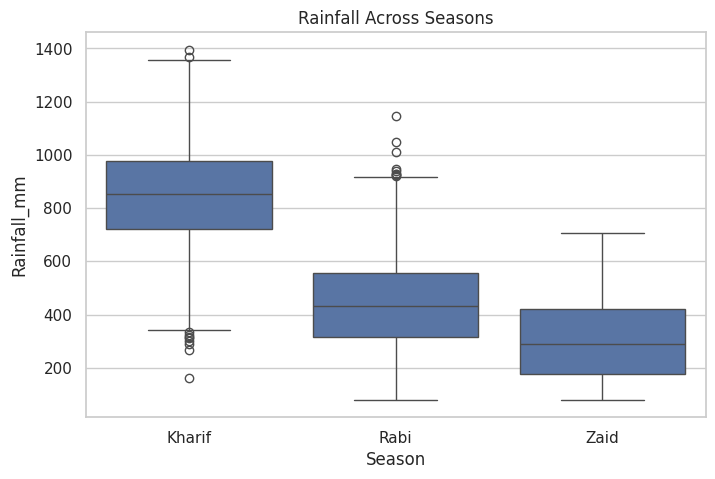

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Rainfall_mm')
plt.title('Rainfall Across Seasons')
plt.show()


### Rainfall vs Yield


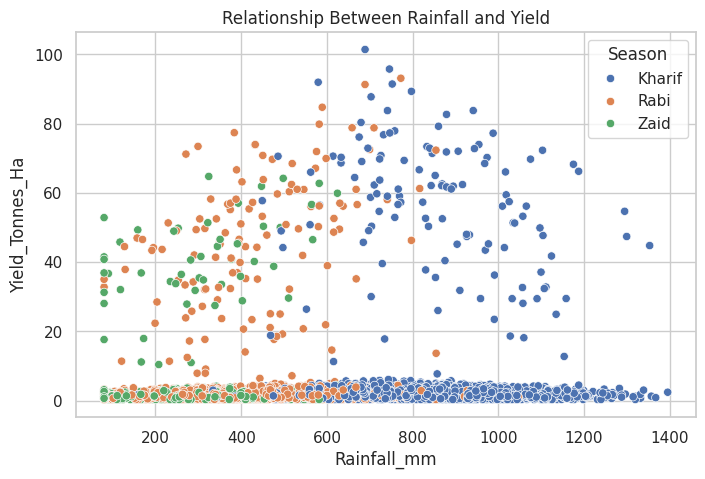

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Relationship Between Rainfall and Yield')
plt.show()


### Fertilizer Usage vs Yield


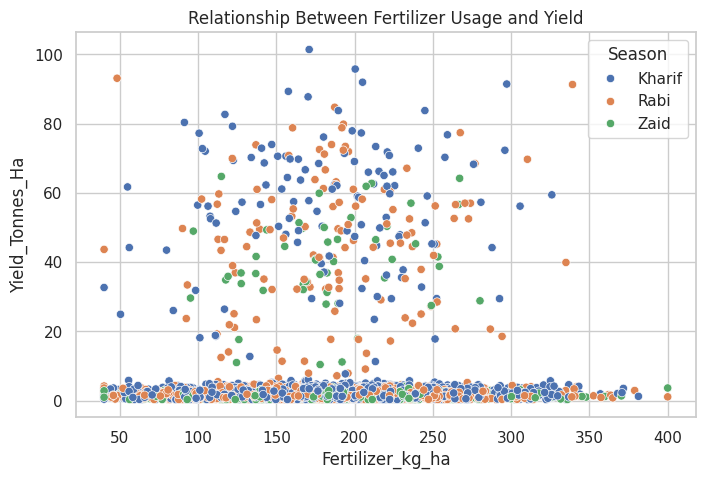

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Relationship Between Fertilizer Usage and Yield')
plt.show()


### Temperature vs Yield


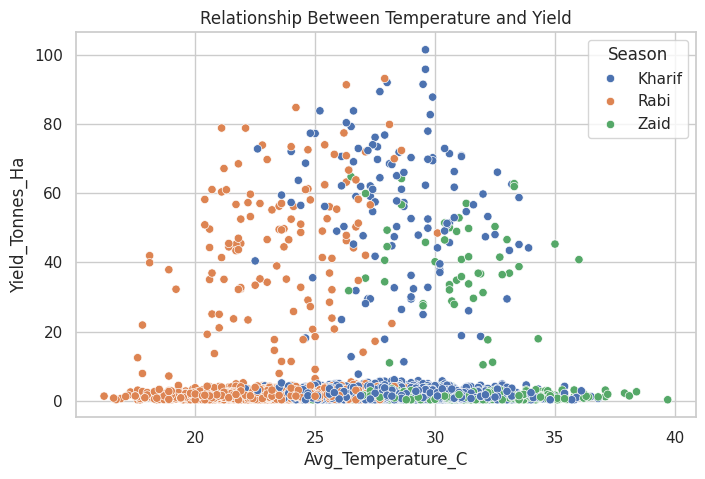

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Relationship Between Temperature and Yield')
plt.show()


### Disease/Pest Risk vs Yield


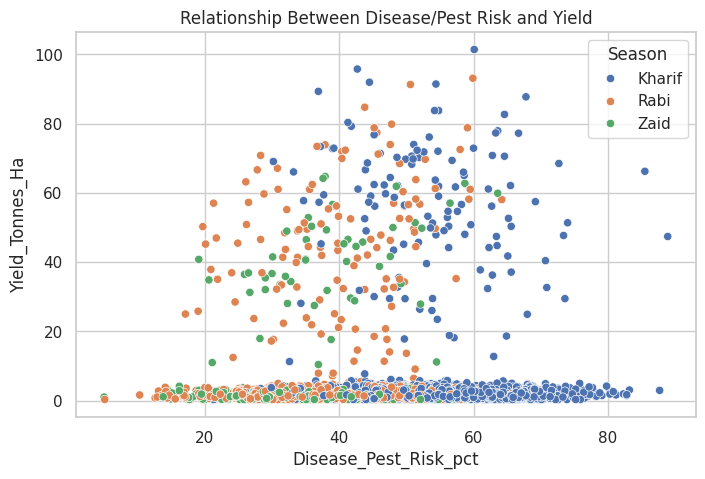

In [42]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Relationship Between Disease/Pest Risk and Yield')
plt.show()


## 11. Multivariate Analysis


### Crop, Season and Yield


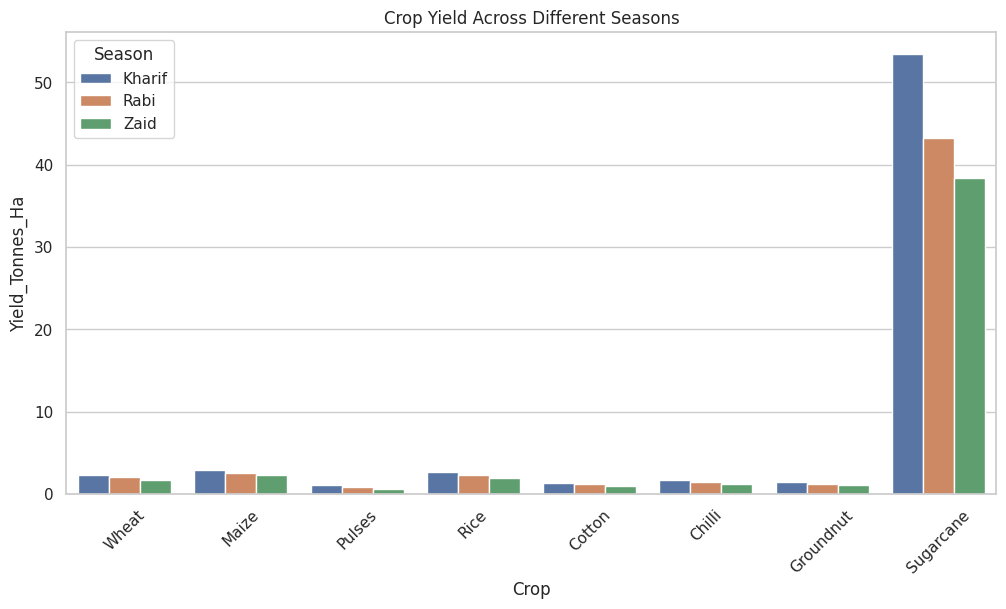

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', errorbar=None)
plt.title('Crop Yield Across Different Seasons')
plt.xticks(rotation=45)
plt.show()


### Irrigation Method, Season and Yield


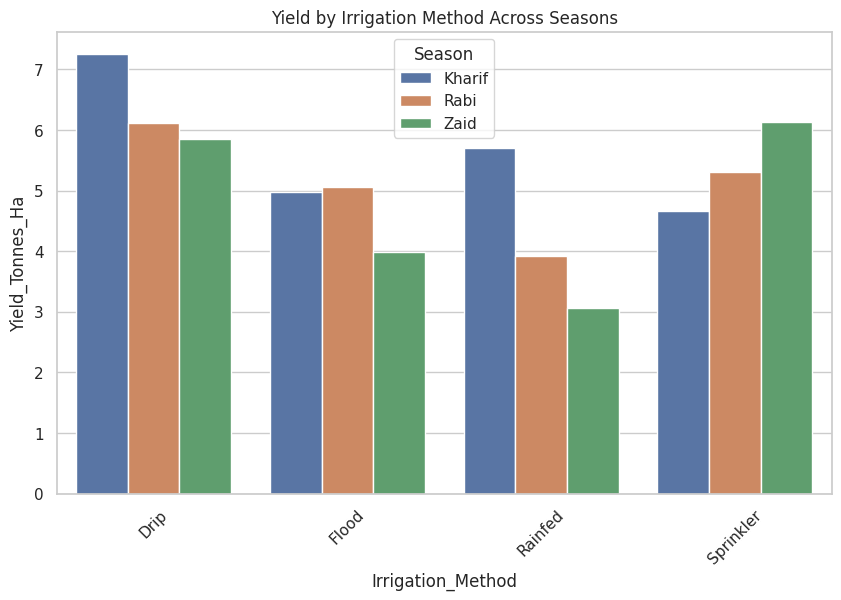

In [44]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Season', errorbar=None)
plt.title('Yield by Irrigation Method Across Seasons')
plt.xticks(rotation=45)
plt.show()


### Crop, Season and Profit


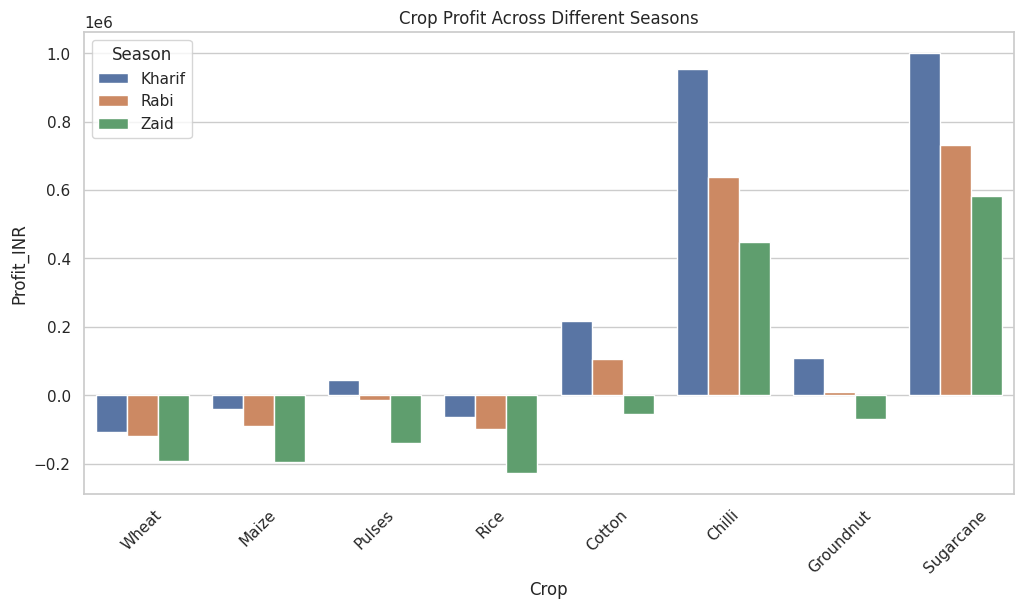

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Crop', y='Profit_INR', hue='Season', errorbar=None)
plt.title('Crop Profit Across Different Seasons')
plt.xticks(rotation=45)
plt.show()


### Rainfall, Temperature and Yield by Season


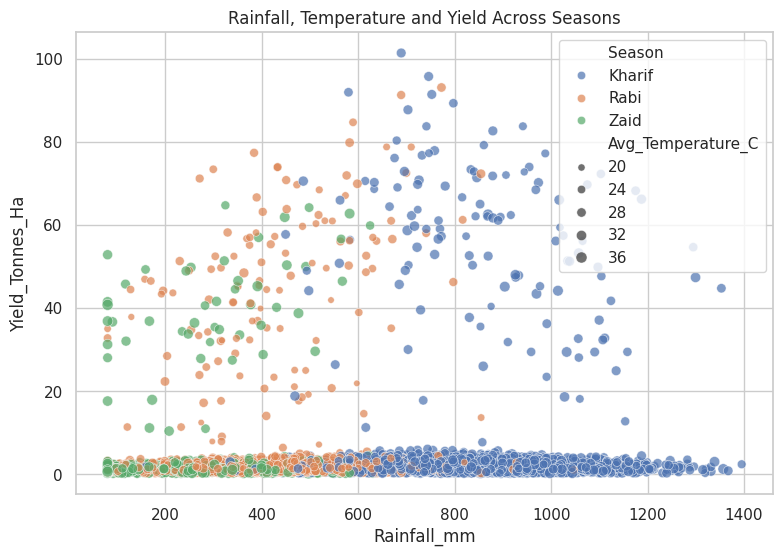

In [46]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    size='Avg_Temperature_C',
    hue='Season',
    alpha=0.7
)
plt.title('Rainfall, Temperature and Yield Across Seasons')
plt.show()


## 12. Correlation Analysis


### Correlation Matrix


In [47]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
correlation_matrix.round(2)


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,...,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,...,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,...,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,...,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,...,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,...,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,...,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,...,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,...,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,...,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


### Correlation Heatmap


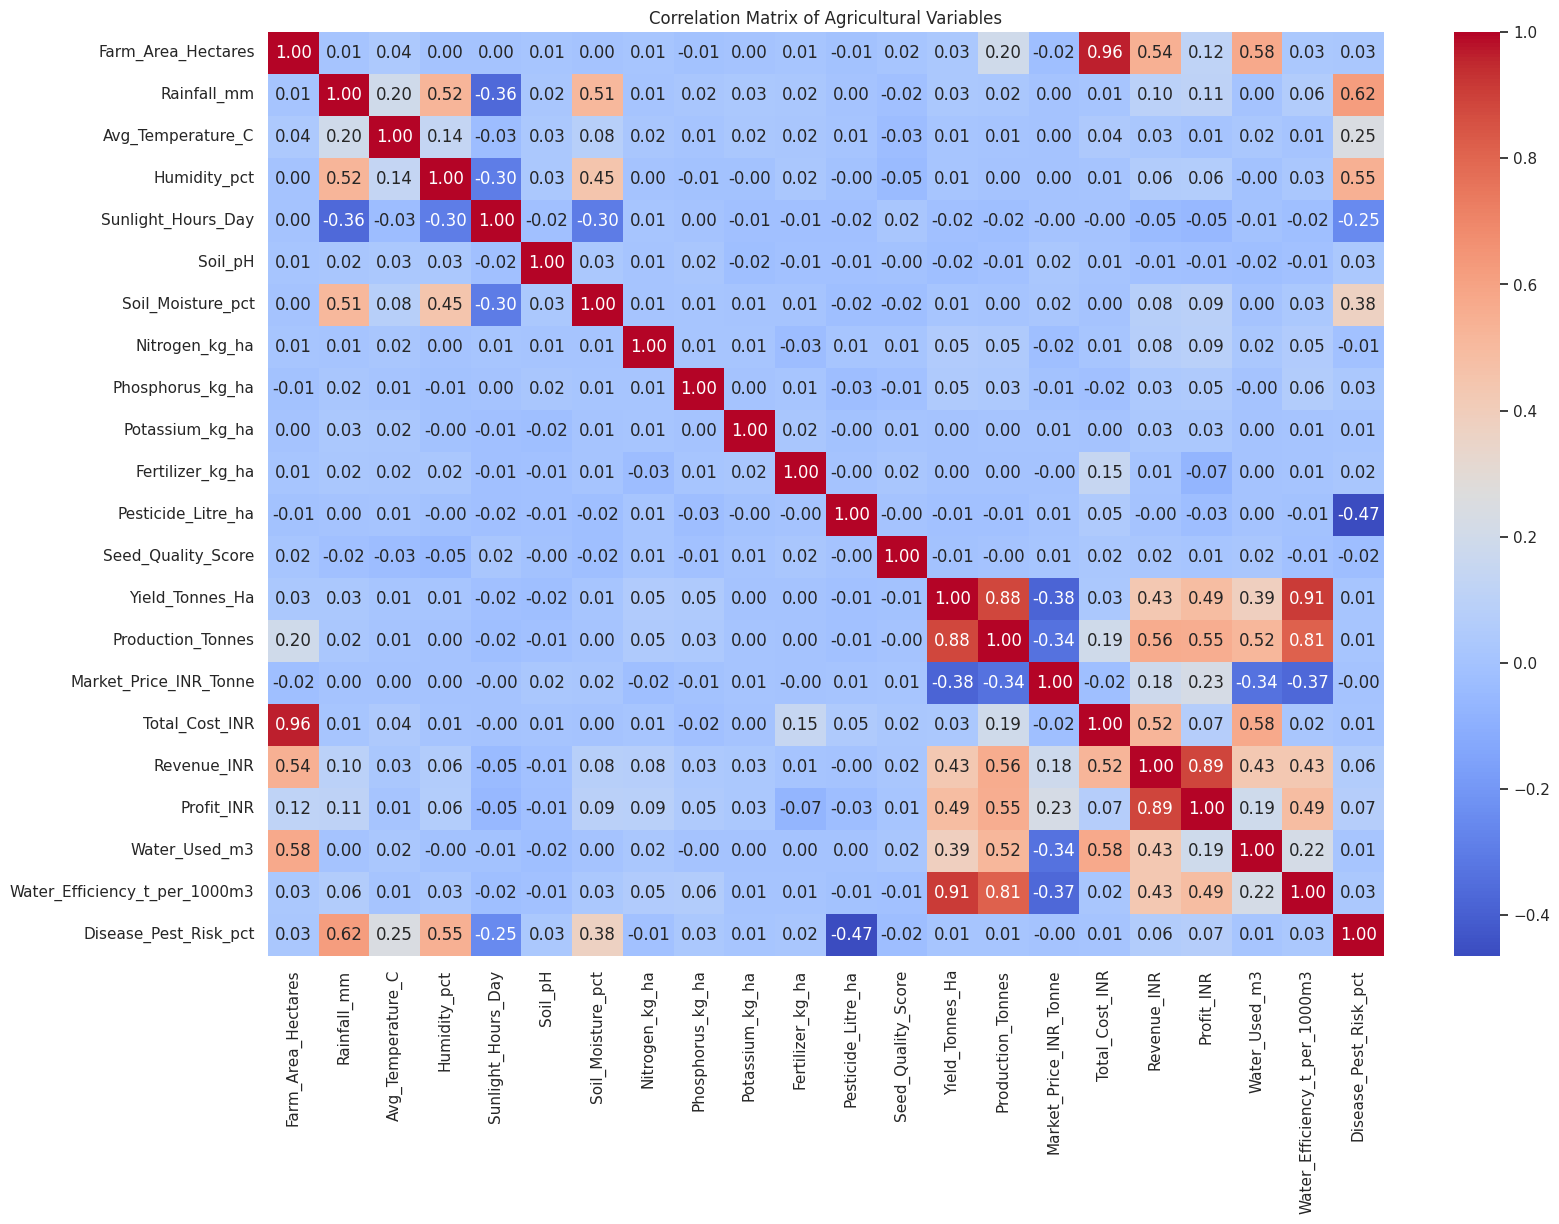

In [48]:
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Agricultural Variables')
plt.show()


### Variables Most Correlated With Yield


In [49]:
yield_correlation = correlation_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)
yield_correlation


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


### Variables Most Correlated With Profit


In [50]:
profit_correlation = correlation_matrix['Profit_INR'].sort_values(ascending=False)
profit_correlation


,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


## 13. Seasonal Comparison


### Overall Seasonal Performance


In [51]:
season_columns = [
    'Yield_Tonnes_Ha', 'Production_Tonnes', 'Rainfall_mm',
    'Avg_Temperature_C', 'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3', 'Revenue_INR',
    'Total_Cost_INR', 'Profit_INR', 'Disease_Pest_Risk_pct'
]
season_columns = [col for col in season_columns if col in df.columns]

season_summary = df.groupby('Season')[season_columns].mean().round(2)
season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Water_Efficiency_t_per_1000m3,Revenue_INR,Total_Cost_INR,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,,
Kharif,5.63,46.31,849.20,28.45,6102.20,5.89,710719.06,531804.41,178914.65,54.47
Rabi,5.04,41.49,437.62,23.49,5846.99,5.19,601526.05,513836.58,87689.47,40.48
Zaid,4.64,38.89,304.65,31.04,6419.89,4.41,519171.90,543976.73,-24804.82,38.22


### Environmental Conditions by Season


In [52]:
environmental_columns = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_Moisture_pct'
]
environmental_columns = [col for col in environmental_columns if col in df.columns]

df.groupby('Season')[environmental_columns].mean().round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


### Yield Comparison by Season


In [53]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).round(2)


,Yield_Tonnes_Ha
Season,
Kharif,5.63
Rabi,5.04
Zaid,4.64


### Production Comparison by Season


In [54]:
df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False).round(2)


,Production_Tonnes
Season,
Kharif,46.31
Rabi,41.49
Zaid,38.89


### Resource Usage Comparison by Season


In [55]:
resource_columns = [
    'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
    'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3'
]
resource_columns = [col for col in resource_columns if col in df.columns]

df.groupby('Season')[resource_columns].mean().round(2)


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


### Water Efficiency Comparison by Season


In [56]:
water_summary = df.groupby('Season')[
    ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
].mean().round(2)

water_summary


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


### Economic Performance Comparison by Season


In [57]:
economic_summary = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean().round(2)

economic_summary


,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


## 14. Additional Student-Driven Analysis


### Profitability per Hectare


In [58]:
df['Profit_per_Hectare'] = df['Profit_INR'] / df['Farm_Area_Hectares']

profit_per_hectare = df.groupby('Season')['Profit_per_Hectare'].mean().sort_values(ascending=False).round(2)
profit_per_hectare


,Profit_per_Hectare
Season,
Kharif,21881.81
Rabi,10361.68
Zaid,-2636.52


### Irrigation Method Performance by Season


In [59]:
irrigation_analysis = df.groupby(['Season', 'Irrigation_Method']).agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

irrigation_analysis


Average_Yield  Average_Profit  Average_Water_Used  \
Season Irrigation_Method                                                      
Kharif Drip                        7.26       317222.07             5953.37   
       Flood                       4.98       133373.83             8229.27   
       Rainfed                     5.70       158974.13             3687.52   
       Sprinkler                   4.66       116880.49             5863.27   
Rabi   Drip                        6.11       187843.22             5911.41   
       Flood                       5.06        58824.80             7766.83   
       Rainfed                     3.93        45232.48             3298.29   
       Sprinkler                   5.31        76502.07             6129.09   
Zaid   Drip                        5.85        21291.84             5837.99   
       Flood                       3.98       -69786.78             8113.69   
       Rainfed                     3.06       -79467.26             3879.39   
       Sprinkler                   6.14        57909.40             7324.41   

                          Average_Water_Efficiency  
Season Irrigation_Method                            
Kharif Drip                                   6.80  
       Flood                                  3.64  
       Rainfed                                8.85  
       Sprinkler                              4.62  
Rabi   Drip                                   6.05  
       Flood                                  3.48  
       Rainfed                                6.87  
       Sprinkler                              4.64  
Zaid   Drip                                   5.30  
       Flood                                  2.73  
       Rainfed                                5.48  
       Sprinkler                              4.86

### Best Performing Crops by Season


In [60]:
crop_season_performance = df.groupby(['Season', 'Crop']).agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

crop_season_performance


Average_Yield  Average_Profit
Season Crop                                    
Kharif Chilli              1.73       954380.42
       Cotton              1.37       216999.55
       Groundnut           1.48       108265.44
       Maize               2.97       -39332.67
       Pulses              1.04        43338.90
       Rice                2.70       -64903.40
       Sugarcane          53.46      1000790.81
       Wheat               2.25      -105871.87
Rabi   Chilli              1.47       638572.50
       Cotton              1.20       107343.59
       Groundnut           1.23        10416.54
       Maize               2.60       -89133.40
       Pulses              0.88       -14309.14
       Rice                2.32       -98427.87
       Sugarcane          43.29       731612.86
       Wheat               2.06      -119954.57
Zaid   Chilli              1.20       448659.09
       Cotton              0.96       -53925.34
       Groundnut           1.04       -68872.50
       Maize               2.29      -194049.17
       Pulses              0.67      -139227.81
       Rice                1.90      -227239.34
       Sugarcane          38.42       583635.80
       Wheat               1.75      -193208.95

### Disease/Pest Risk and Profit


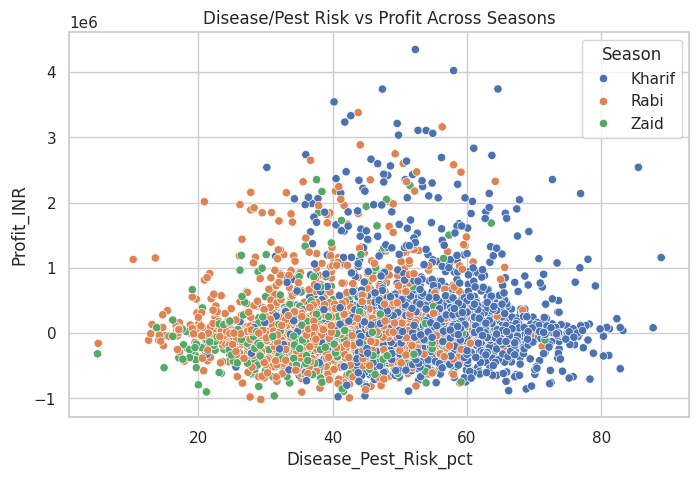

In [61]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season')
plt.title('Disease/Pest Risk vs Profit Across Seasons')
plt.show()


### Water Efficiency and Yield


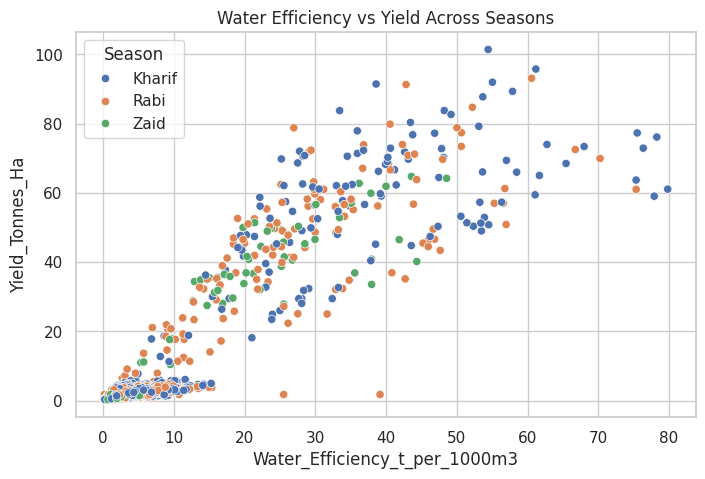

In [62]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Water_Efficiency_t_per_1000m3', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Water Efficiency vs Yield Across Seasons')
plt.show()


## 15. Key Insights


Write at least 8 meaningful insights from the analysis.

### Insight 1

**Observation:** Kharif recorded the highest average agricultural yield among the three seasons.

**Evidence:** The average yield was 5.63 tonnes per hectare in Kharif, compared with 5.04 tonnes per hectare in Rabi and 4.64 tonnes per hectare in Zaid.

**Interpretation:** Agricultural performance in terms of yield was highest during Kharif in this dataset.

**Limitation:** This does not prove that the Kharif season itself caused the higher yield, as crop type, irrigation method and other factors may also influence the result.

---

### Insight 2

**Observation:** Kharif also recorded the highest average production.

**Evidence:** Average production was 46.31 tonnes in Kharif, compared with 41.49 tonnes in Rabi and 38.89 tonnes in Zaid.

**Interpretation:** The higher yield observed during Kharif was accompanied by higher overall agricultural production.

**Limitation:** Production can also be influenced by farm area, crop type and other farming conditions, so the seasonal comparison alone cannot explain the complete reason.

---

### Insight 3

**Observation:** Kharif was the most profitable season, while Zaid recorded an average loss.

**Evidence:** Average profit was ₹178,914.65 in Kharif and ₹87,689.47 in Rabi. Zaid had an average profit of -₹24,804.82.

**Interpretation:** Among the three seasons, Kharif showed the strongest economic performance, whereas the average revenue in Zaid was not sufficient to cover the average total cost.

**Limitation:** Average profit does not mean that every farm in Kharif was profitable or every farm in Zaid made a loss.

---

### Insight 4

**Observation:** Kharif received substantially higher rainfall and also had the highest average soil moisture.

**Evidence:** Average rainfall was 849.20 mm in Kharif, compared with 437.62 mm in Rabi and 304.65 mm in Zaid. Average soil moisture was also highest in Kharif at 31.15%.

**Interpretation:** Kharif had wetter environmental conditions in the dataset, which coincided with the highest average yield and production.

**Limitation:** The analysis shows an association only and cannot conclude that higher rainfall directly caused the higher agricultural performance.

---

### Insight 5

**Observation:** Zaid had the highest average temperature but the lowest average yield and production.

**Evidence:** The average temperature was 31.04°C in Zaid, compared with 28.45°C in Kharif and 23.49°C in Rabi. Zaid's average yield was 4.64 tonnes per hectare and average production was 38.89 tonnes, both the lowest among the seasons.

**Interpretation:** Higher temperatures in the Zaid records were associated with lower average agricultural performance compared with Kharif and Rabi.

**Limitation:** Temperature should not be considered the only explanation because crop selection, water availability and other variables may also affect yield.

---

### Insight 6

**Observation:** Water efficiency was highest in Kharif and lowest in Zaid.

**Evidence:** Average water efficiency was 5.89 tonnes per 1000 m³ in Kharif, 5.19 in Rabi and 4.41 in Zaid.

**Interpretation:** Kharif achieved better agricultural output relative to water efficiency, while Zaid showed comparatively lower efficiency.

**Limitation:** Water efficiency is a derived performance measure and may vary depending on crop type and farming practices.

---

### Insight 7

**Observation:** Yield had a strong positive correlation with water efficiency and production.

**Evidence:** The correlation between yield and water efficiency was approximately 0.91, while the correlation between yield and production was approximately 0.88.

**Interpretation:** Higher-yield records were strongly associated with higher water efficiency and higher production in the dataset.

**Limitation:** Correlation does not establish causation. These relationships do not prove that increasing water efficiency alone will cause yield to increase.

---

### Insight 8

**Observation:** Drip irrigation showed strong performance across seasons, particularly in Kharif and Rabi.

**Evidence:** Average yield under drip irrigation was 7.26 tonnes per hectare in Kharif and 6.11 tonnes per hectare in Rabi. In Kharif, average profit under drip irrigation was approximately ₹317,222.07, while in Rabi it was approximately ₹187,843.22.

**Interpretation:** Drip irrigation was associated with comparatively strong yield and profitability in these seasonal groups.

**Limitation:** The dataset does not prove that drip irrigation alone produced better results because farms using different irrigation methods may differ in crops, farm conditions and other inputs.

## 16. Recommendations


Based only on the evidence found in the dataset, provide practical and data-driven recommendations.

### Recommendation 1: Prioritize planning for strong Kharif performance

The analysis showed that Kharif had the highest average yield, production, revenue, profit and water efficiency. Agricultural planning should therefore focus on maintaining the farming practices and resource conditions associated with strong Kharif performance.

**Evidence:** Kharif recorded an average yield of 5.63 tonnes per hectare and an average profit of ₹178,914.65.

**Important Limitation:** These results describe the available dataset and should not be interpreted as proof that Kharif will always be the most profitable season.

---

### Recommendation 2: Investigate and improve Zaid season profitability

Zaid recorded the lowest average yield and production and an average negative profit. Farms and stakeholders should investigate the major cost, revenue, crop selection and resource usage patterns during Zaid to identify opportunities for improvement.

**Evidence:** Zaid recorded an average profit of -₹24,804.82, with average revenue of ₹519,171.90 being lower than the average total cost of ₹543,976.73.

**Important Limitation:** Further investigation is required before identifying a single reason for the negative average profit.

---

### Recommendation 3: Focus on improving water efficiency

Water efficiency showed a strong positive association with agricultural yield. Seasonal planning should therefore examine practices that improve efficient water use, while considering crop-specific requirements.

**Evidence:** Yield and water efficiency had a strong positive correlation of approximately 0.91. Kharif, which had the highest water efficiency of 5.89 tonnes per 1000 m³, also had the highest average yield.

**Important Limitation:** The correlation does not prove that improving water efficiency alone will increase yield.

---

### Recommendation 4: Further evaluate drip irrigation practices

Drip irrigation showed strong average yield and profit results, especially during Kharif and Rabi. It should be further evaluated as a potentially useful irrigation approach for suitable crops and locations.

**Evidence:** Drip irrigation recorded an average yield of 7.26 tonnes per hectare in Kharif and 6.11 tonnes per hectare in Rabi.

**Important Limitation:** Before making a general recommendation, irrigation performance should also be compared after considering crop type, farm conditions and implementation costs.

---

### Recommendation 5: Use season-specific crop planning

Crop performance varied across seasonal conditions. Crop selection and planning should therefore be based on observed seasonal performance rather than assuming that one crop performs equally well throughout the year.

**Evidence:** The crop and season analysis showed noticeable differences in average yield and profit across seasonal groups.

**Important Limitation:** The observed results are based only on the crops and records available in this dataset.

---

### Recommendation 6: Monitor environmental and economic factors together

Agricultural planning should not rely only on yield. Rainfall, temperature, soil moisture, water usage, production costs, revenue and profit should be reviewed together for each season.

**Evidence:** Kharif, Rabi and Zaid showed clear differences in environmental conditions as well as economic outcomes.

**Important Limitation:** The analysis identifies patterns and relationships within the available data and cannot establish direct causal relationships between individual variables.

## 17. Conclusion


This project analyzes how agricultural performance varies across seasons using environmental, production, resource usage and economic variables.

The final conclusion should summarize the major seasonal differences, important relationships, unusual patterns, key insights and practical recommendations supported by the dataset.


## 18. Project Checklist


Before submission, confirm that the notebook includes:

- [ ] Dataset loaded successfully
- [ ] Top 5 rows analyzed
- [ ] Dataset shape and structure examined
- [ ] Data types examined
- [ ] Missing values identified and handled
- [ ] Duplicate records identified and handled
- [ ] Descriptive/statistical analysis performed
- [ ] Outliers investigated
- [ ] Univariate analysis completed
- [ ] Bivariate analysis completed
- [ ] Multivariate analysis completed
- [ ] Correlation analysis completed
- [ ] Seasonal comparisons performed
- [ ] At least 3 student-designed analyses completed
- [ ] At least 8 meaningful insights documented
- [ ] Evidence-based recommendations provided
- [ ] Limitations discussed
- [ ] Final conclusion provided


### Limitations


- The analysis is limited to the variables available in the dataset.
- Correlation identifies relationships but does not prove causation.
- Missing value treatment may influence some results.
- Extreme values may influence averages and statistical summaries.
- Other real-world factors affecting agricultural performance may not be included in the dataset.
